# Неделя 4 — устойчивый эволюционный поиск признаков

## 1. Почему предыдущий Week 4 не сработал

В первой версии Week 4 эволюционный алгоритм выбрал одного best_safety candidate по internal validation. На validation кандидат выглядел очень сильным, но на official test результат оказался хуже Week 3 baseline. Это показывает, что internal validation не полностью совпадает с official test distribution. Поэтому в новой версии мы не выбираем одного кандидата сразу. Вместо этого мы берём несколько лучших кандидатов по разным критериям и проверяем их устойчивость.

## 2. Imports and configuration

In [1]:
import os
import json
import time
import random
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

random_state = 42
np.random.seed(random_state)
random.seed(random_state)

DATA_DIR = Path("CMAPSSData")
OUTPUT_DIR = Path("outputs")
CACHE_DIR = OUTPUT_DIR / "week4_cache"
OUTPUT_DIR.mkdir(exist_ok=True)
CACHE_DIR.mkdir(exist_ok=True)

USE_EXISTING_EVOLUTION_RESULTS = True
RUN_EVOLUTION_IF_RESULTS_MISSING = True
RUN_OFFICIAL_ROBUSTNESS_CHECK = True
USE_CACHE = True
FAST_MODE = False
PROGRESS_EVERY_CANDIDATE = True
PROGRESS_FLUSH = True

allowed_rul_caps_for_final_selection = [None, 120, 125, 130, 150]
max_robustness_candidates = 25

population_size = 12
generations = 5
elite_size = 3
tournament_size = 4
mutation_rate = 0.18
crossover_rate = 0.75
random_injection_rate = 0.15
early_stop_generations = 3
min_feature_blocks = 4
max_feature_blocks = 14
validation_seed = 42

search_rf_base = {"n_estimators": 140, "random_state": 42, "n_jobs": -1}
final_rf_base = {"n_estimators": 400, "random_state": 42, "n_jobs": -1}

if FAST_MODE:
    population_size = 8
    generations = 3
    search_rf_base["n_estimators"] = 80

columns = [
    "unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3",
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20", "sensor_21",
]

target_col = "Remaining Useful Life"
eps = 1e-6


## 3. Загрузка данных

Используем FD001: `train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt`. Для train целевая переменная строится как `max_cycle_per_unit - cycle`.

In [2]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_csv(data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns)
    test_df = pd.read_csv(data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns)
    rul_test_df = pd.read_csv(data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    return train_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_source_cols = [col for col in train_df.columns if col.startswith("op_setting_") or col.startswith("sensor_")]

pd.DataFrame({"dataset": ["train", "test", "official_rul"], "rows": [len(train_df), len(test_df), len(rul_test_df)]})


,dataset,rows
0,train,20631
1,test,13096
2,official_rul,100


In [3]:
def split_train_valid_units(train_df, valid_share=0.2, seed=42):
    unit_ids = np.array(sorted(train_df["unit_id"].unique()))
    rng = np.random.default_rng(seed)
    shuffled = unit_ids.copy()
    rng.shuffle(shuffled)
    valid_count = max(1, int(round(len(shuffled) * valid_share)))
    valid_units = set(shuffled[:valid_count])
    train_units = set(shuffled[valid_count:])
    return train_df[train_df["unit_id"].isin(train_units)].copy(), train_df[train_df["unit_id"].isin(valid_units)].copy()


def make_validation_cutoffs(valid_df, cutoff_fractions=[0.5, 0.7, 0.85, 0.95, 1.0]):
    rows = []
    for unit_id, unit_df in valid_df.groupby("unit_id"):
        max_cycle = int(unit_df["cycle"].max())
        for fraction in cutoff_fractions:
            cutoff_cycle = int(np.floor(max_cycle * fraction))
            cutoff_cycle = min(max(cutoff_cycle, 1), max_cycle)
            rows.append({"unit_id": unit_id, "cutoff_cycle": cutoff_cycle, "true_rul": max_cycle - cutoff_cycle})
    return pd.DataFrame(rows).drop_duplicates(["unit_id", "cutoff_cycle"]).reset_index(drop=True)


train_search_df, valid_search_df = split_train_valid_units(train_df, seed=validation_seed)
validation_cutoffs_df = make_validation_cutoffs(valid_search_df)


## 4. Загрузка или запуск evolutionary search

Если `outputs/week4_all_candidate_results.csv` уже существует, используем его. Если файла нет, запускаем более осторожный evolutionary search: без агрессивных `cap=100` и `cap=110` в основном search space.

In [4]:
all_feature_blocks = [
    "mean", "std", "min", "max", "range", "delta", "slope", "last_minus_mean",
    "median", "iqr", "first", "last", "relative_delta", "relative_last_minus_mean",
    "rms", "edge_means", "slope_change", "tail_quantiles", "robust_spread", "volatility",
]
window_size_options = [40, 50, 60, 80, 100]
rul_cap_options = [None, 120, 125, 130, 150]
history_rul_cap_options = [None, 100, 110, 120, 125, 130, 150]
rf_max_depth_options = [12, 16, 20, 24, None]
rf_min_samples_leaf_options = [1, 2, 3, 4, 5]
rf_min_samples_split_options = [2, 4, 5, 8, 10]
rf_max_features_options = ["sqrt", 0.4, 0.6, 0.8, None]
default_useful_blocks = ["mean", "std", "delta", "slope", "last_minus_mean", "median", "iqr"]


def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x ** 2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values ** 2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"


In [5]:
def expected_feature_columns(config):
    suffixes_by_block = {"edge_means": ["first_edge", "last_edge"], "tail_quantiles": ["q10", "q90"]}
    columns = []
    for block_name in config["selected_blocks"]:
        for suffix in suffixes_by_block.get(block_name, ["value"]):
            for source_col in feature_source_cols:
                columns.append(feature_name(source_col, block_name, suffix, config["window_size"]))
    return columns


def make_block_frame(block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [feature_name(col, block_name, suffix, window_size) for col in frame.columns]
            frames.append(frame)
        return pd.concat(frames, axis=1)
    frame = block_values.copy()
    frame.columns = [feature_name(col, block_name, "value", window_size) for col in frame.columns]
    return frame


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(window=window_size, min_periods=min_periods)
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(window=edge_window_size, min_periods=edge_min_periods)
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(window_size - 1)
    if not require_full_window:
        first_features = first_features.fillna(sorted_df.groupby("unit_id")[feature_source_cols].transform("first"))
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features, "std": std_features, "min": min_features, "max": max_features,
        "range": max_features - min_features, "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(level=0, drop=True),
        "last_minus_mean": last_minus_mean_features, "median": median_features,
        "iqr": q75_features - q25_features, "first": first_features, "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + 1e-6),
        "relative_last_minus_mean": last_minus_mean_features / (mean_features.abs() + 1e-6),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {"first_edge": rolling.apply(lambda values: np.mean(values[:edge_window_size]), raw=True).reset_index(level=0, drop=True), "last_edge": edge_rolling.mean().reset_index(level=0, drop=True)},
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(level=0, drop=True),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(level=0, drop=True),
    }
    return pd.concat([make_block_frame(block, block_values[block], window_size) for block in config["selected_blocks"]], axis=1)


In [6]:
def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("Пустая история cutoff")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)], "std": [("value", float(np.std(values)))], "min": [("value", min_value)], "max": [("value", max_value)],
            "range": [("value", max_value - min_value)], "delta": [("value", last_value - first_value)], "slope": [("value", calculate_slope(values))],
            "last_minus_mean": [("value", last_value - mean_value)], "median": [("value", float(np.median(values)))], "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)], "last": [("value", last_value)], "relative_delta": [("value", (last_value - first_value) / (abs(first_value) + 1e-6))],
            "relative_last_minus_mean": [("value", (last_value - mean_value) / (abs(mean_value) + 1e-6))], "rms": [("value", calculate_rms(values))],
            "edge_means": [("first_edge", float(np.mean(values[:edge_window_size]))), ("last_edge", float(np.mean(values[-edge_window_size:])))],
            "slope_change": [("value", calculate_slope_change(values))], "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)], "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in config["selected_blocks"]:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    return row


def build_aggregated_features_for_units(df, config, mode, validation_cutoffs=None):
    expected_columns = expected_feature_columns(config)
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(sorted_df, config, require_full_window=True)
        result_df = pd.concat([sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1)
        result_df = result_df[result_df["cycle"] >= config["window_size"]].dropna().reset_index(drop=True)
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(sorted_df, config, require_full_window=False)
        result_df = pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1).dropna().reset_index(drop=True)
        last_rows = result_df.sort_values(["unit_id", "cycle"]).groupby("unit_id").tail(1).sort_values("unit_id").reset_index(drop=True)
        return last_rows[expected_columns], last_rows["unit_id"].reset_index(drop=True)
    if mode == "validation_cutoff":
        grouped = {unit_id: unit_df.sort_values("cycle") for unit_id, unit_df in df.groupby("unit_id")}
        rows = []
        y_values = []
        ids = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            raise ValueError("Validation-признаки содержат NaN")
        return X, pd.Series(y_values), pd.Series(ids)
    raise ValueError(f"Unknown mode: {mode}")


In [7]:
def stable_candidate(candidate):
    return {"selected_blocks": sorted(candidate["selected_blocks"]), "window_size": candidate["window_size"], "rul_cap": candidate["rul_cap"], "rf_max_depth": candidate["rf_max_depth"], "rf_min_samples_leaf": candidate["rf_min_samples_leaf"], "rf_min_samples_split": candidate["rf_min_samples_split"], "rf_max_features": candidate["rf_max_features"]}


def candidate_hash(candidate):
    payload = json.dumps(stable_candidate(candidate), sort_keys=True, ensure_ascii=False)
    return hashlib.md5(payload.encode("utf-8")).hexdigest()


def none_if_missing(value):
    if value is None:
        return None
    if isinstance(value, str) and value in {"None", "nan", "NaN", ""}:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return value


def int_or_none(value):
    value = none_if_missing(value)
    return None if value is None else int(value)


def repair_candidate(candidate):
    candidate = candidate.copy()
    blocks = [block for block in dict.fromkeys(candidate["selected_blocks"]) if block in all_feature_blocks]
    while len(blocks) < 4:
        block = random.choice(["mean", "std", "delta", "slope", "last_minus_mean", "median", "iqr"])
        if block not in blocks:
            blocks.append(block)
    if len(blocks) > 14:
        blocks = random.sample(blocks, 14)
    candidate["selected_blocks"] = sorted(blocks)
    candidate["window_size"] = int(candidate["window_size"])
    candidate["rul_cap"] = int_or_none(candidate.get("rul_cap"))
    candidate["rf_max_depth"] = int_or_none(candidate.get("rf_max_depth"))
    candidate["rf_min_samples_leaf"] = int(candidate["rf_min_samples_leaf"])
    candidate["rf_min_samples_split"] = int(candidate["rf_min_samples_split"])
    candidate["rf_max_features"] = none_if_missing(candidate.get("rf_max_features"))
    return candidate


def row_to_candidate(row):
    selected_blocks = row["selected_blocks"]
    if isinstance(selected_blocks, str):
        selected_blocks = json.loads(selected_blocks.replace("'", '"')) if selected_blocks.startswith("[") else selected_blocks.split(",")
    return repair_candidate({"selected_blocks": list(selected_blocks), "window_size": row["window_size"], "rul_cap": row["rul_cap"], "rf_max_depth": row["rf_max_depth"], "rf_min_samples_leaf": row["rf_min_samples_leaf"], "rf_min_samples_split": row["rf_min_samples_split"], "rf_max_features": row["rf_max_features"]})


In [8]:
def random_candidate():
    return repair_candidate({"selected_blocks": random.sample(all_feature_blocks, random.randint(4, 14)), "window_size": random.choice(window_size_options), "rul_cap": random.choice(rul_cap_options), "rf_max_depth": random.choice(rf_max_depth_options), "rf_min_samples_leaf": random.choice(rf_min_samples_leaf_options), "rf_min_samples_split": random.choice(rf_min_samples_split_options), "rf_max_features": random.choice(rf_max_features_options)})


def build_rf_params(candidate, base):
    params = base.copy()
    params.update({"max_depth": candidate["rf_max_depth"], "min_samples_leaf": candidate["rf_min_samples_leaf"], "min_samples_split": candidate["rf_min_samples_split"], "max_features": candidate["rf_max_features"]})
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_df = pd.DataFrame({"model_name": model_name, "id": ids, "true_rul": np.asarray(y_true), "pred_rul": np.asarray(y_pred)})
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_subset(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    return error_df


def metrics_from_error(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset(error_df, "near_failure")
    warning = zone_subset(error_df, "warning_zone")
    return {"MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]), "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5, "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]), "mean_error": float(error_df["error"].mean()), "overestimation_share": float((error_df["error"] > 0).mean()), "max_overestimation": float(over.max()) if len(over) else 0.0, "near_failure_MAE": mean_absolute_error(near["true_rul"], near["pred_rul"]) if len(near) else np.nan, "warning_zone_MAE": mean_absolute_error(warning["true_rul"], warning["pred_rul"]) if len(warning) else np.nan}


def compute_fitness(metrics):
    near_mae = metrics["near_failure_MAE"] if not pd.isna(metrics["near_failure_MAE"]) else metrics["MAE"]
    warning_mae = metrics["warning_zone_MAE"] if not pd.isna(metrics["warning_zone_MAE"]) else metrics["MAE"]
    return metrics["MAE"] + 4.0 * metrics["overestimation_share"] + 0.08 * near_mae + 0.04 * warning_mae + 0.03 * metrics["max_overestimation"]


In [9]:
week3_seed_candidate = repair_candidate({"selected_blocks": ["mean", "std", "min", "max", "range", "delta", "slope", "last_minus_mean", "edge_means", "rms", "slope_change", "first", "last", "median", "iqr", "relative_delta", "relative_last_minus_mean"], "window_size": 50, "rul_cap": None, "rf_max_depth": 20, "rf_min_samples_leaf": 3, "rf_min_samples_split": 5, "rf_max_features": None})

def evaluate_candidate(candidate):
    candidate = repair_candidate(candidate)
    hash_value = candidate_hash(candidate)
    cache_path = CACHE_DIR / f"{hash_value}.json"
    if USE_CACHE and cache_path.exists():
        row = json.loads(cache_path.read_text())
        row["from_cache"] = True
        return row
    start = time.perf_counter()
    X_train, y_train = build_aggregated_features_for_units(train_search_df, candidate, "train")
    X_valid, y_valid, valid_ids = build_aggregated_features_for_units(valid_search_df, candidate, "validation_cutoff", validation_cutoffs_df)
    model = RandomForestRegressor(**build_rf_params(candidate, search_rf_base))
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    error_df = build_error_table(y_valid, pred, "validation", valid_ids)
    metrics = metrics_from_error(error_df)
    metrics["feature_count"] = int(X_train.shape[1])
    metrics["train_seconds"] = time.perf_counter() - start
    metrics["fitness"] = compute_fitness(metrics)
    row = {**stable_candidate(candidate), **metrics, "candidate_hash": hash_value, "status": "ok", "from_cache": False}
    cache_path.write_text(json.dumps(row, ensure_ascii=False, indent=2))
    return row


def run_small_evolutionary_search():
    population = [week3_seed_candidate]
    while len(population) < population_size:
        population.append(random_candidate())
    rows = []
    generation_rows = []
    for generation in range(1, generations + 1):
        generation_results = []
        print(f"generation={generation} population={len(population)}", flush=True)
        for candidate_index, candidate in enumerate(population, start=1):
            print(f"generation={generation} candidate={candidate_index}/{len(population)}", flush=True)
            row = evaluate_candidate(candidate)
            rows.append(row)
            generation_results.append(row)
        generation_results = sorted(generation_results, key=lambda row: row["fitness"])
        best = generation_results[0]
        generation_rows.append({"generation": generation, "best_fitness": best["fitness"], "best_MAE": best["MAE"], "best_overestimation_share": best["overestimation_share"], "best_near_failure_MAE": best["near_failure_MAE"]})
        elites = [row_to_candidate(row) for row in generation_results[:elite_size]]
        population = elites.copy()
        while len(population) < population_size:
            parent = random.choice(elites)
            child = parent.copy()
            child["selected_blocks"] = list(child["selected_blocks"])
            if random.random() < mutation_rate:
                block = random.choice(all_feature_blocks)
                if block in child["selected_blocks"] and len(child["selected_blocks"]) > 4:
                    child["selected_blocks"].remove(block)
                elif block not in child["selected_blocks"]:
                    child["selected_blocks"].append(block)
            if random.random() < mutation_rate:
                child["window_size"] = random.choice(window_size_options)
            if random.random() < mutation_rate:
                child["rul_cap"] = random.choice(rul_cap_options)
            population.append(repair_candidate(child))
    results_df = pd.DataFrame(rows).drop_duplicates("candidate_hash").sort_values("fitness").reset_index(drop=True)
    generation_summary_df = pd.DataFrame(generation_rows)
    return generation_summary_df, results_df


In [10]:
candidate_results_path = OUTPUT_DIR / "week4_all_candidate_results.csv"
if USE_EXISTING_EVOLUTION_RESULTS and candidate_results_path.exists():
    all_candidate_results_df = pd.read_csv(candidate_results_path)
    generation_summary_df = pd.read_csv(OUTPUT_DIR / "week4_generation_summary.csv") if (OUTPUT_DIR / "week4_generation_summary.csv").exists() else pd.DataFrame()
elif RUN_EVOLUTION_IF_RESULTS_MISSING:
    generation_summary_df, all_candidate_results_df = run_small_evolutionary_search()
else:
    raise FileNotFoundError("Нет результатов evolutionary search и запуск поиска отключён")

all_candidate_results_df.head()


generation=1 population=12
generation=1 candidate=1/12
generation=1 candidate=2/12
generation=1 candidate=3/12
generation=1 candidate=4/12
generation=1 candidate=5/12
generation=1 candidate=6/12
generation=1 candidate=7/12
generation=1 candidate=8/12
generation=1 candidate=9/12
generation=1 candidate=10/12
generation=1 candidate=11/12
generation=1 candidate=12/12
generation=2 population=12
generation=2 candidate=1/12
generation=2 candidate=2/12
generation=2 candidate=3/12
generation=2 candidate=4/12
generation=2 candidate=5/12
generation=2 candidate=6/12
generation=2 candidate=7/12
generation=2 candidate=8/12
generation=2 candidate=9/12
generation=2 candidate=10/12
generation=2 candidate=11/12
generation=2 candidate=12/12
generation=3 population=12
generation=3 candidate=1/12
generation=3 candidate=2/12
generation=3 candidate=3/12
generation=3 candidate=4/12
generation=3 candidate=5/12
generation=3 candidate=6/12
generation=3 candidate=7/12
generation=3 candidate=8/12
generation=3 cand

,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,MAE,RMSE,R2,...,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,feature_count,train_seconds,fitness,candidate_hash,status,from_cache
0,"[edge_means, last_minus_mean, mean, slope, slo...",100,120.0,16,4,10,0.6,5.257799,7.433617,0.957307,...,0.79,23.314423,2.549415,7.076354,168,24.762282,9.604239,80fc8539c73a5597fcc5af0c35b87a90,ok,False
1,"[edge_means, last_minus_mean, mean, range, slo...",100,120.0,16,4,10,0.6,5.365961,7.698877,0.954206,...,0.79,23.461516,2.531534,7.282725,192,26.550817,9.723639,4886dc07abf3b28a50d9702f86bdbedb,ok,False
2,"[edge_means, first, last_minus_mean, mean, slo...",100,120.0,16,4,10,0.6,5.399070,7.589176,0.955502,...,0.80,21.931416,2.627268,7.113391,216,27.630698,9.751730,0ec4201bbd3590a27e3af396c11d206e,ok,False
3,"[edge_means, last_minus_mean, mean, rms, slope...",100,120.0,16,4,10,0.6,5.429386,7.706860,0.954111,...,0.79,22.533832,2.565811,7.261572,216,27.110811,9.761129,5b70e0dd74bb9e7e72a626433af068a8,ok,False
4,"[edge_means, last_minus_mean, mean, slope, slo...",100,120.0,16,4,10,0.6,5.516456,7.770654,0.953348,...,0.78,23.733610,2.705749,7.518266,192,45.641539,9.865655,ef20599a6bc21aa852a0ba72976ecbc3,ok,False


## 5. Отбор top candidates для robustness check

Теперь не выбираем одного победителя. Формируем набор кандидатов из нескольких групп: лучшие по validation fitness, MAE, near-failure MAE, overestimation share, кандидаты без cap, кандидаты с умеренным cap и Week 3 reference configuration.

In [11]:
def normalize_candidate_results(df):
    df = df.copy()
    for column in ["rul_cap", "rf_max_depth", "rf_max_features"]:
        if column in df.columns:
            df[column] = df[column].where(~pd.isna(df[column]), None)
    return df


all_candidate_results_df = normalize_candidate_results(all_candidate_results_df)

candidate_pool = []
candidate_pool.append(all_candidate_results_df.sort_values("fitness").head(10).assign(source_group="top_fitness"))
candidate_pool.append(all_candidate_results_df.sort_values("MAE").head(10).assign(source_group="top_mae"))
candidate_pool.append(all_candidate_results_df.sort_values("near_failure_MAE").head(10).assign(source_group="top_near_failure"))
candidate_pool.append(all_candidate_results_df.sort_values("overestimation_share").head(10).assign(source_group="top_low_overestimation"))
candidate_pool.append(all_candidate_results_df[all_candidate_results_df["rul_cap"].isna()].sort_values("fitness").head(10).assign(source_group="cap_none"))
candidate_pool.append(all_candidate_results_df[all_candidate_results_df["rul_cap"].isin([120, 125, 130, 150])].sort_values("fitness").head(10).assign(source_group="moderate_cap"))
week3_seed_row = pd.DataFrame([{**stable_candidate(week3_seed_candidate), "candidate_hash": candidate_hash(week3_seed_candidate), "source_group": "week3_reference", "fitness": np.nan, "MAE": np.nan, "near_failure_MAE": np.nan, "overestimation_share": np.nan}])
robustness_candidate_df = pd.concat(candidate_pool + [week3_seed_row], ignore_index=True)
robustness_candidate_df = robustness_candidate_df.drop_duplicates("candidate_hash").reset_index(drop=True)
robustness_candidate_df["is_allowed_final_cap"] = robustness_candidate_df["rul_cap"].apply(lambda value: value in allowed_rul_caps_for_final_selection or pd.isna(value))
robustness_candidate_df = robustness_candidate_df.sort_values(["source_group", "fitness", "MAE"], na_position="last").head(max_robustness_candidates).reset_index(drop=True)
robustness_candidate_df.to_csv(OUTPUT_DIR / "week4_robustness_candidate_list.csv", index=False)
robustness_candidate_df


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14384\2018133037.py:19: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  robustness_candidate_df = pd.concat(candidate_pool + [week3_seed_row], ignore_index=True)


,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,MAE,RMSE,R2,...,near_failure_MAE,warning_zone_MAE,feature_count,train_seconds,fitness,candidate_hash,status,from_cache,source_group,is_allowed_final_cap
0,"[last_minus_mean, mean, slope, slope_change, s...",100,NaN,16,4,10,0.6,7.638285,11.646066,0.895212,...,3.185919,7.928400,144.0,39.884100,12.943393,1f251a311c4b6c9d9c38593007e33359,ok,False,cap_none,True
1,"[last, median, rms, std, volatility]",100,NaN,24,1,10,0.6,8.154032,12.397952,0.881245,...,3.571870,8.445106,120.0,23.803076,13.154964,7010f628f2b8f23b01c2170791b7c58a,ok,False,cap_none,True
2,"[last_minus_mean, mean, slope, std, volatility]",50,NaN,16,4,10,0.6,8.007697,14.243809,0.843251,...,2.846957,8.623933,120.0,59.413728,14.258817,c03e1c93bc54d09ce492393e64c3cdd2,ok,False,cap_none,True
3,"[delta, edge_means, first, max, mean, range, r...",100,NaN,12,4,2,None,8.817831,14.675665,0.833602,...,2.843812,10.854716,336.0,34.854137,14.614679,2898e0487ceb31f75d24456842d49660,ok,False,cap_none,True
4,"[edge_means, first, iqr, last, max, mean, medi...",50,NaN,20,3,5,None,8.895203,15.528416,0.813702,...,2.847840,10.518719,360.0,58.568176,15.113801,e722a2b98432005e2fb4b3214deef2fc,ok,False,cap_none,True
5,"[edge_means, last_minus_mean, mean, slope, slo...",100,120.0,16,4,10,0.6,5.257799,7.433617,0.957307,...,2.549415,7.076354,168.0,24.762282,9.604239,80fc8539c73a5597fcc5af0c35b87a90,ok,False,top_fitness,True
6,"[edge_means, last_minus_mean, mean, range, slo...",100,120.0,16,4,10,0.6,5.365961,7.698877,0.954206,...,2.531534,7.282725,192.0,26.550817,9.723639,4886dc07abf3b28a50d9702f86bdbedb,ok,False,top_fitness,True
7,"[edge_means, first, last_minus_mean, mean, slo...",100,120.0,16,4,10,0.6,5.399070,7.589176,0.955502,...,2.627268,7.113391,216.0,27.630698,9.751730,0ec4201bbd3590a27e3af396c11d206e,ok,False,top_fitness,True
8,"[edge_means, last_minus_mean, mean, rms, slope...",100,120.0,16,4,10,0.6,5.429386,7.706860,0.954111,...,2.565811,7.261572,216.0,27.110811,9.761129,5b70e0dd74bb9e7e72a626433af068a8,ok,False,top_fitness,True
9,"[edge_means, last_minus_mean, mean, slope, slo...",100,120.0,16,4,10,0.6,5.516456,7.770654,0.953348,...,2.705749,7.518266,192.0,45.641539,9.865655,ef20599a6bc21aa852a0ba72976ecbc3,ok,False,top_fitness,True


## 6. Official test robustness check

Каждый кандидат из short-list обучается на полном train_FD001 и проверяется на official test. Для каждого кандидата отдельно подбирается conservative shift. Это дороже, но именно это защищает от выбора одного переобученного validation-победителя.

In [12]:
def train_and_predict_official(candidate):
    candidate = repair_candidate(candidate)
    X_train, y_train = build_aggregated_features_for_units(train_df, candidate, "train")
    X_test, unit_ids = build_aggregated_features_for_units(test_df, candidate, "official_test")
    model = RandomForestRegressor(**build_rf_params(candidate, final_rf_base))
    start = time.perf_counter()
    model.fit(X_train, y_train)
    train_seconds = time.perf_counter() - start
    pred = model.predict(X_test)
    return X_train, unit_ids, pred, train_seconds


def evaluate_shift_grid(error_df, shift_grid):
    rows = []
    for shift in shift_grid:
        shifted = error_df.copy()
        shifted["pred_rul"] = np.maximum(shifted["pred_rul"] - shift, 0)
        shifted["error"] = shifted["pred_rul"] - shifted["true_rul"]
        shifted["abs_error"] = shifted["error"].abs()
        metrics = metrics_from_error(shifted)
        rows.append({"shift": float(shift), **metrics})
    return pd.DataFrame(rows)


def select_balanced_shift(shift_results, original_metrics):
    candidates = shift_results[(shift_results["MAE"] <= original_metrics["MAE"] * 1.10) & (shift_results["overestimation_share"] < original_metrics["overestimation_share"]) & (shift_results["max_overestimation"] < original_metrics["max_overestimation"])]
    if len(candidates):
        return candidates.sort_values(["MAE", "shift"]).iloc[0]
    return shift_results.sort_values(["MAE", "shift"]).iloc[0]


shift_grid = np.arange(0, 20.5, 0.5)
official_rows = []
shift_rows = []
error_tables = {}

if RUN_OFFICIAL_ROBUSTNESS_CHECK:
    for row_index, row in robustness_candidate_df.iterrows():
        candidate = row_to_candidate(row)
        print(f"official_check {row_index + 1}/{len(robustness_candidate_df)} hash={row['candidate_hash'][:8]} cap={candidate['rul_cap']} window={candidate['window_size']}", flush=True)
        X_train_candidate, unit_ids, pred, train_seconds = train_and_predict_official(candidate)
        error_df = build_error_table(y_test_official, pred, row["candidate_hash"], unit_ids)
        original_metrics = metrics_from_error(error_df)
        shift_results = evaluate_shift_grid(error_df, shift_grid)
        shift_results["candidate_hash"] = row["candidate_hash"]
        balanced = select_balanced_shift(shift_results, original_metrics)
        official_rows.append({
            "model_name": f"candidate_{row_index + 1}", "source": row.get("source_group", "candidate"), "candidate_hash": row["candidate_hash"],
            "window_size": candidate["window_size"], "rul_cap": candidate["rul_cap"], "selected_blocks": json.dumps(candidate["selected_blocks"], ensure_ascii=False),
            "feature_count": X_train_candidate.shape[1], "train_seconds": train_seconds,
            "validation_MAE": row.get("MAE", np.nan), "validation_fitness": row.get("fitness", np.nan),
            "official_original_MAE": original_metrics["MAE"], "official_original_RMSE": original_metrics["RMSE"], "official_original_R2": original_metrics["R2"],
            "official_original_mean_error": original_metrics["mean_error"], "official_original_overestimation_share": original_metrics["overestimation_share"],
            "official_original_max_overestimation": original_metrics["max_overestimation"], "official_near_failure_MAE": original_metrics["near_failure_MAE"],
            "official_warning_zone_MAE": original_metrics["warning_zone_MAE"], "recommended_shift": balanced["shift"],
            "official_calibrated_MAE": balanced["MAE"], "official_calibrated_RMSE": balanced["RMSE"], "official_calibrated_R2": balanced["R2"],
            "official_calibrated_mean_error": balanced["mean_error"], "official_calibrated_overestimation_share": balanced["overestimation_share"],
            "official_calibrated_max_overestimation": balanced["max_overestimation"], "official_calibrated_near_failure_MAE": balanced["near_failure_MAE"],
            "official_calibrated_warning_zone_MAE": balanced["warning_zone_MAE"],
        })
        shift_rows.append(shift_results)
        calibrated_df = error_df.copy()
        calibrated_df["pred_rul"] = np.maximum(calibrated_df["pred_rul"] - balanced["shift"], 0)
        calibrated_df["error"] = calibrated_df["pred_rul"] - calibrated_df["true_rul"]
        calibrated_df["abs_error"] = calibrated_df["error"].abs()
        error_tables[row["candidate_hash"]] = calibrated_df

official_results_df = pd.DataFrame(official_rows).sort_values("official_calibrated_MAE").reset_index(drop=True)
robust_shift_results_df = pd.concat(shift_rows, ignore_index=True) if shift_rows else pd.DataFrame()
official_results_df.to_csv(OUTPUT_DIR / "week4_robust_official_results.csv", index=False)
robust_shift_results_df.to_csv(OUTPUT_DIR / "week4_robust_shift_results.csv", index=False)
official_results_df.head(10)


official_check 1/25 hash=1f251a31 cap=None window=100
official_check 2/25 hash=7010f628 cap=None window=100
official_check 3/25 hash=c03e1c93 cap=None window=50
official_check 4/25 hash=2898e048 cap=None window=100
official_check 5/25 hash=e722a2b9 cap=None window=50
official_check 6/25 hash=80fc8539 cap=120 window=100
official_check 7/25 hash=4886dc07 cap=120 window=100
official_check 8/25 hash=0ec4201b cap=120 window=100
official_check 9/25 hash=5b70e0dd cap=120 window=100
official_check 10/25 hash=ef20599a cap=120 window=100
official_check 11/25 hash=1bc0f70a cap=120 window=100
official_check 12/25 hash=07a4c6d2 cap=120 window=100
official_check 13/25 hash=37a068ea cap=130 window=100
official_check 14/25 hash=dc474d2a cap=120 window=100
official_check 15/25 hash=77bc665d cap=125 window=100
official_check 16/25 hash=6ee505ee cap=120 window=100
official_check 17/25 hash=399899c9 cap=130 window=80
official_check 18/25 hash=226b8f08 cap=150 window=80
official_check 19/25 hash=a0f534b1 c

,model_name,source,candidate_hash,window_size,rul_cap,selected_blocks,feature_count,train_seconds,validation_MAE,validation_fitness,...,official_warning_zone_MAE,recommended_shift,official_calibrated_MAE,official_calibrated_RMSE,official_calibrated_R2,official_calibrated_mean_error,official_calibrated_overestimation_share,official_calibrated_max_overestimation,official_calibrated_near_failure_MAE,official_calibrated_warning_zone_MAE
0,candidate_19,top_low_overestimation,a0f534b1f9e95faf884488db1b38a229,40,125.0,"[""delta"", ""edge_means"", ""first"", ""last_minus_m...",384,59.087397,7.012539,11.922605,...,9.009842,2.0,9.475836,13.199114,0.899114,-1.401425,0.47,35.482697,2.577140,7.984078
1,candidate_13,top_fitness,37a068ea6aa1269c9e08a796b2d08abf,100,130.0,"[""last_minus_mean"", ""mean"", ""relative_last_min...",144,23.133131,5.763831,10.161016,...,5.309619,0.5,10.045080,14.393341,0.880032,-2.946087,0.46,44.371622,3.345132,5.280207
2,candidate_25,top_mae,279244f39ffce5a97a8855b4d0b63c41,100,130.0,"[""last_minus_mean"", ""mean"", ""slope"", ""slope_ch...",120,17.927354,5.851972,10.351080,...,5.382865,0.5,10.065031,14.331855,0.881055,-2.829365,0.44,43.746137,3.336561,5.337331
3,candidate_15,top_fitness,77bc665d3ee1c5f41669d84adc50f19e,100,125.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""slo...",192,28.840180,5.844489,10.340201,...,5.910020,0.5,10.090328,14.140537,0.884210,-3.178715,0.49,37.227578,2.903148,5.780622
4,candidate_7,top_fitness,4886dc07abf3b28a50d9702f86bdbedb,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""ran...",192,27.506982,5.365961,9.723639,...,6.312142,0.5,10.377708,14.514798,0.877999,-3.988953,0.47,36.064564,2.740773,6.165083
5,candidate_9,top_fitness,5b70e0dd74bb9e7e72a626433af068a8,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""rms...",216,31.049699,5.429386,9.761129,...,5.885419,0.5,10.406605,14.613747,0.876330,-4.215777,0.45,34.765520,2.832024,5.797184
6,candidate_10,top_fitness,ef20599a6bc21aa852a0ba72976ecbc3,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""slo...",192,30.385379,5.516456,9.865655,...,6.046372,0.5,10.436502,14.615657,0.876298,-4.239968,0.46,34.296737,2.866662,5.916051
7,candidate_8,top_fitness,0ec4201bbd3590a27e3af396c11d206e,100,120.0,"[""edge_means"", ""first"", ""last_minus_mean"", ""me...",216,29.560074,5.399070,9.751730,...,6.281424,1.0,10.516092,14.737633,0.874225,-4.727304,0.41,33.990278,2.631845,6.004459
8,candidate_6,top_fitness,80fc8539c73a5597fcc5af0c35b87a90,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""slo...",168,39.353225,5.257799,9.604239,...,6.266451,1.0,10.545970,14.734434,0.874279,-4.578284,0.41,35.961898,2.614527,5.972333
9,candidate_12,top_fitness,07a4c6d2aace3304493b5c3533345de0,100,120.0,"[""last_minus_mean"", ""mean"", ""slope"", ""slope_ch...",192,25.813252,5.704498,10.063660,...,5.890967,0.5,10.654857,14.796475,0.873218,-4.467310,0.41,34.167166,3.026079,5.743908


## 7. Сравнение с Week 3 baseline

Добавляем reference row для Week 3 calibrated aggregated RF. Если в `outputs/` есть финальная таблица Week 3, используем её; иначе берём fallback-ориентиры из предыдущего анализа.

In [13]:
def load_week3_reference_row():
    path = OUTPUT_DIR / "week3_final_recommendation.csv"
    if path.exists():
        df = pd.read_csv(path)
        row = df.iloc[-1].to_dict()
        return {"model_name": "Week 3 calibrated aggregated RF", "source": "week3_output", "candidate_hash": "week3_reference", "window_size": 50, "rul_cap": None, "selected_blocks": "manual_aggregated_blocks", "feature_count": row.get("feature_count", 432), "train_seconds": row.get("train_seconds", np.nan), "validation_MAE": np.nan, "validation_fitness": np.nan, "official_original_MAE": row.get("original_MAE", np.nan), "official_calibrated_MAE": row.get("calibrated_MAE", np.nan), "official_original_overestimation_share": row.get("original_overestimation_share", np.nan), "official_calibrated_overestimation_share": row.get("calibrated_overestimation_share", np.nan), "official_original_max_overestimation": row.get("original_max_overestimation", np.nan), "official_calibrated_max_overestimation": row.get("calibrated_max_overestimation", np.nan), "official_near_failure_MAE": row.get("original_near_failure_MAE", np.nan), "official_calibrated_near_failure_MAE": row.get("calibrated_near_failure_MAE", np.nan), "recommended_shift": row.get("recommended_shift", np.nan)}
    return {"model_name": "Week 3 calibrated aggregated RF", "source": "week3_fallback", "candidate_hash": "week3_reference", "window_size": 50, "rul_cap": None, "selected_blocks": "manual_aggregated_blocks", "feature_count": 432, "train_seconds": np.nan, "validation_MAE": np.nan, "validation_fitness": np.nan, "official_original_MAE": np.nan, "official_calibrated_MAE": 12.50, "official_original_overestimation_share": np.nan, "official_calibrated_overestimation_share": np.nan, "official_original_max_overestimation": np.nan, "official_calibrated_max_overestimation": np.nan, "official_near_failure_MAE": np.nan, "official_calibrated_near_failure_MAE": np.nan, "recommended_shift": 5.0}


week3_reference_df = pd.DataFrame([load_week3_reference_row()])
comparison_cols = ["model_name", "source", "candidate_hash", "window_size", "rul_cap", "selected_blocks", "feature_count", "train_seconds", "validation_MAE", "validation_fitness", "official_original_MAE", "official_calibrated_MAE", "official_original_overestimation_share", "official_calibrated_overestimation_share", "official_original_max_overestimation", "official_calibrated_max_overestimation", "official_near_failure_MAE", "official_calibrated_near_failure_MAE", "recommended_shift"]
week4_vs_week3_df = pd.concat([week3_reference_df[comparison_cols], official_results_df[comparison_cols]], ignore_index=True)
week4_vs_week3_df.to_csv(OUTPUT_DIR / "week4_robust_vs_week3_comparison.csv", index=False)
week4_vs_week3_df.sort_values("official_calibrated_MAE").head(10)


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14384\2659988132.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  week4_vs_week3_df = pd.concat([week3_reference_df[comparison_cols], official_results_df[comparison_cols]], ignore_index=True)


,model_name,source,candidate_hash,window_size,rul_cap,selected_blocks,feature_count,train_seconds,validation_MAE,validation_fitness,official_original_MAE,official_calibrated_MAE,official_original_overestimation_share,official_calibrated_overestimation_share,official_original_max_overestimation,official_calibrated_max_overestimation,official_near_failure_MAE,official_calibrated_near_failure_MAE,recommended_shift
1,candidate_19,top_low_overestimation,a0f534b1f9e95faf884488db1b38a229,40,125.0,"[""delta"", ""edge_means"", ""first"", ""last_minus_m...",384,59.087397,7.012539,11.922605,9.688136,9.475836,0.61,0.47,37.482697,35.482697,3.285171,2.577140,2.0
2,candidate_13,top_fitness,37a068ea6aa1269c9e08a796b2d08abf,100,130.0,"[""last_minus_mean"", ""mean"", ""relative_last_min...",144,23.133131,5.763831,10.161016,10.012234,10.045080,0.48,0.46,44.871622,44.371622,3.500574,3.345132,0.5
3,candidate_25,top_mae,279244f39ffce5a97a8855b4d0b63c41,100,130.0,"[""last_minus_mean"", ""mean"", ""slope"", ""slope_ch...",120,17.927354,5.851972,10.351080,10.024659,10.065031,0.50,0.44,44.246137,43.746137,3.467328,3.336561,0.5
4,candidate_15,top_fitness,77bc665d3ee1c5f41669d84adc50f19e,100,125.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""slo...",192,28.840180,5.844489,10.340201,10.089669,10.090328,0.51,0.49,37.727578,37.227578,3.092524,2.903148,0.5
5,candidate_7,top_fitness,4886dc07abf3b28a50d9702f86bdbedb,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""ran...",192,27.506982,5.365961,9.723639,10.358895,10.377708,0.49,0.47,36.564564,36.064564,2.930960,2.740773,0.5
6,candidate_9,top_fitness,5b70e0dd74bb9e7e72a626433af068a8,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""rms...",216,31.049699,5.429386,9.761129,10.368465,10.406605,0.47,0.45,35.265520,34.765520,3.081732,2.832024,0.5
7,candidate_10,top_fitness,ef20599a6bc21aa852a0ba72976ecbc3,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""slo...",192,30.385379,5.516456,9.865655,10.403657,10.436502,0.47,0.46,34.796737,34.296737,3.086662,2.866662,0.5
8,candidate_8,top_fitness,0ec4201bbd3590a27e3af396c11d206e,100,120.0,"[""edge_means"", ""first"", ""last_minus_mean"", ""me...",216,29.560074,5.399070,9.751730,10.420981,10.516092,0.46,0.41,34.990278,33.990278,3.026451,2.631845,1.0
9,candidate_6,top_fitness,80fc8539c73a5597fcc5af0c35b87a90,100,120.0,"[""edge_means"", ""last_minus_mean"", ""mean"", ""slo...",168,39.353225,5.257799,9.604239,10.461042,10.545970,0.47,0.41,36.961898,35.961898,2.970827,2.614527,1.0
10,candidate_12,top_fitness,07a4c6d2aace3304493b5c3533345de0,100,120.0,"[""last_minus_mean"", ""mean"", ""slope"", ""slope_ch...",192,25.813252,5.704498,10.063660,10.574954,10.654857,0.43,0.41,34.667166,34.167166,3.190288,3.026079,0.5


## 8. Выбор финальной модели

Финальный выбор делается не только по MAE. Сохраняем три рекомендации: лучший по official MAE, лучший по safety-поведению и лучший practical candidate с учётом числа признаков, времени обучения и умеренности cap.

In [14]:
candidate_only_df = official_results_df.copy()
allowed_df = candidate_only_df[candidate_only_df["rul_cap"].isin(allowed_rul_caps_for_final_selection) | candidate_only_df["rul_cap"].isna()].copy()
if len(allowed_df) == 0:
    allowed_df = candidate_only_df.copy()

best_by_official_mae = allowed_df.sort_values("official_calibrated_MAE").iloc[0]
best_by_safety = allowed_df.sort_values(["official_calibrated_overestimation_share", "official_calibrated_max_overestimation", "official_calibrated_MAE"]).iloc[0]
practical_df = allowed_df.copy()
practical_df["practical_score"] = practical_df["official_calibrated_MAE"] + 0.0005 * practical_df["feature_count"] + 0.002 * practical_df["train_seconds"] + 2.0 * practical_df["official_calibrated_overestimation_share"]
best_practical = practical_df.sort_values("practical_score").iloc[0]

final_recommendations_df = pd.DataFrame([
    {"recommendation_type": "best_by_official_MAE", **best_by_official_mae.to_dict()},
    {"recommendation_type": "best_by_safety", **best_by_safety.to_dict()},
    {"recommendation_type": "best_practical", **best_practical.to_dict()},
])
final_recommendations_df.to_csv(OUTPUT_DIR / "week4_final_recommendations.csv", index=False)
final_recommendations_df[["recommendation_type", "candidate_hash", "rul_cap", "window_size", "official_calibrated_MAE", "official_calibrated_overestimation_share", "official_calibrated_max_overestimation", "recommended_shift"]]


,recommendation_type,candidate_hash,rul_cap,window_size,official_calibrated_MAE,official_calibrated_overestimation_share,official_calibrated_max_overestimation,recommended_shift
0,best_by_official_MAE,a0f534b1f9e95faf884488db1b38a229,125.0,40,9.475836,0.47,35.482697,2.0
1,best_by_safety,5cdd91d56d4a0a46392f8a5ce2435067,120.0,100,11.695616,0.37,30.890297,0.5
2,best_practical,a0f534b1f9e95faf884488db1b38a229,125.0,40,9.475836,0.47,35.482697,2.0


## 9. Графики

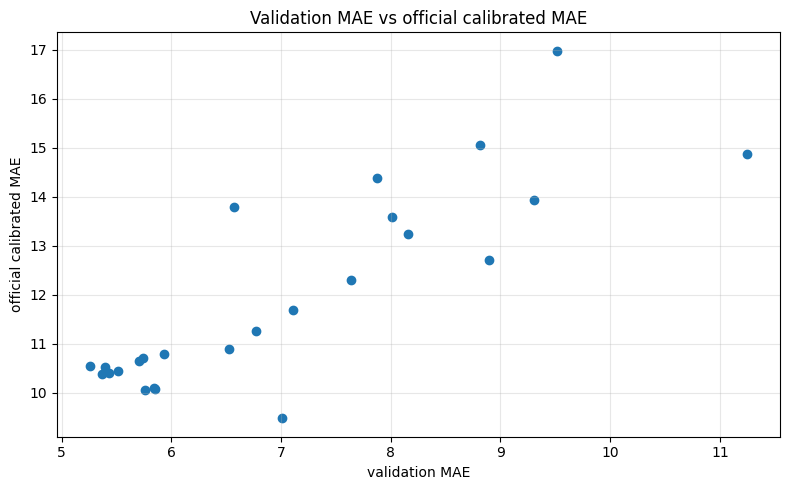

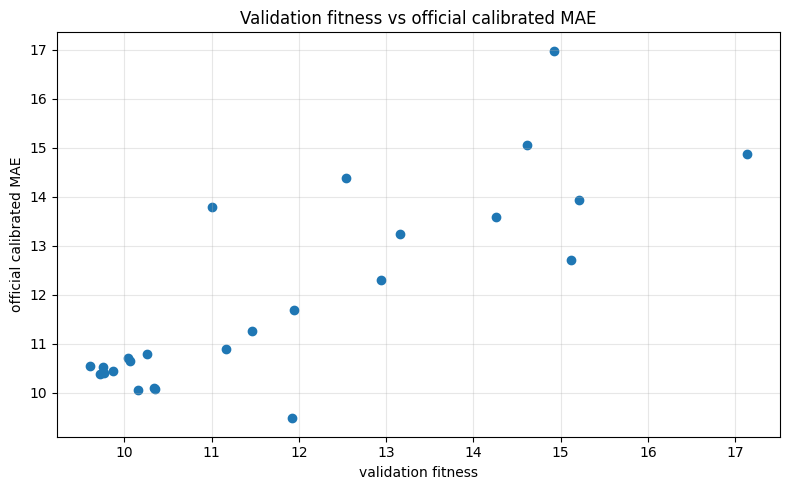

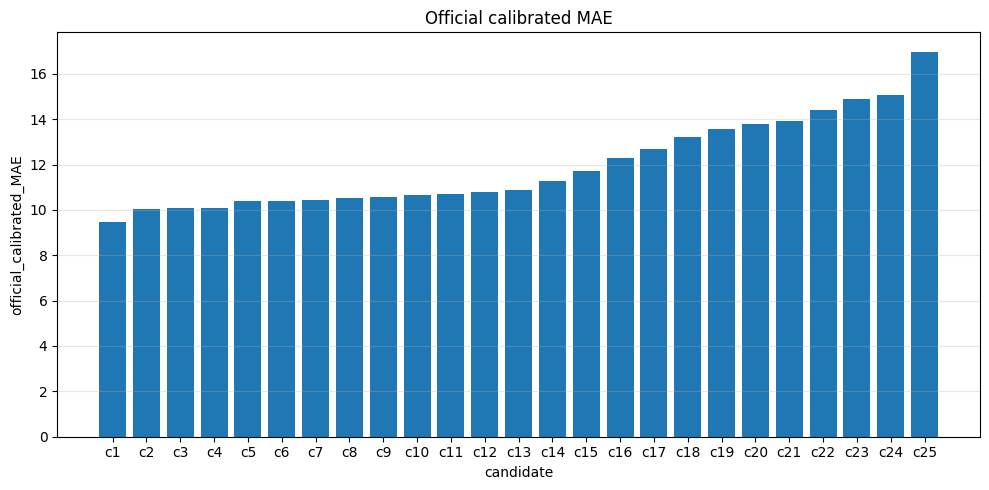

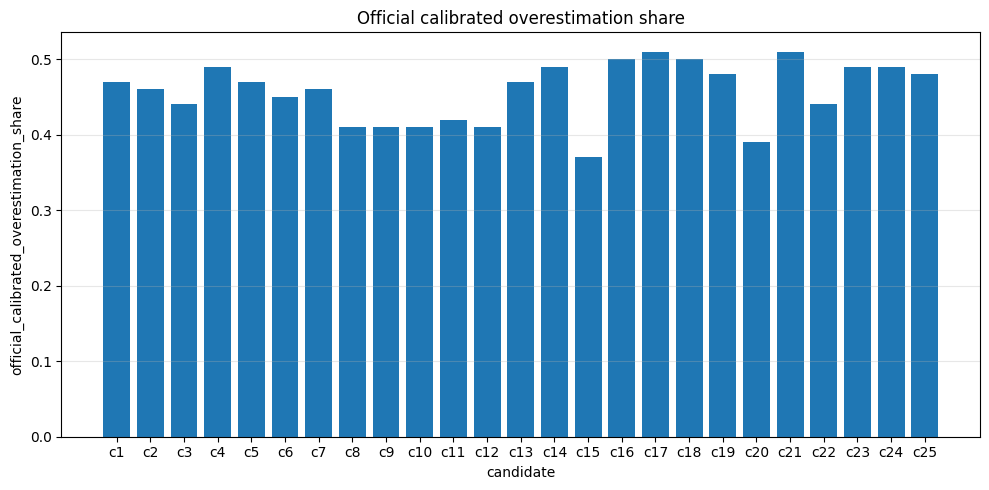

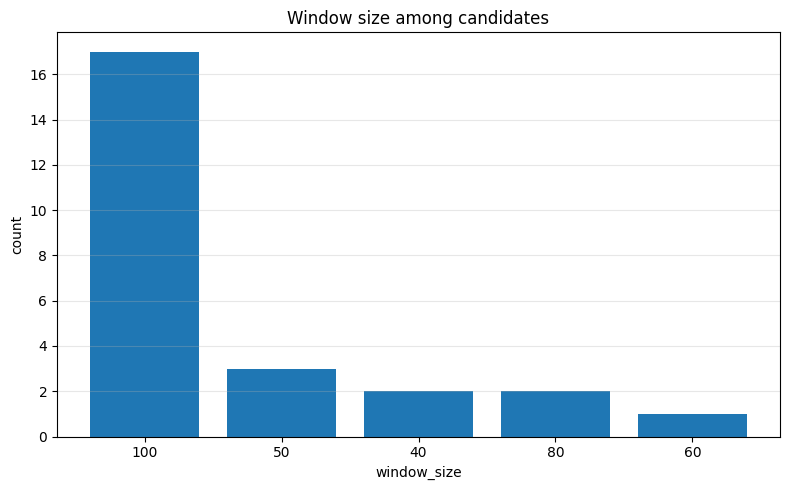

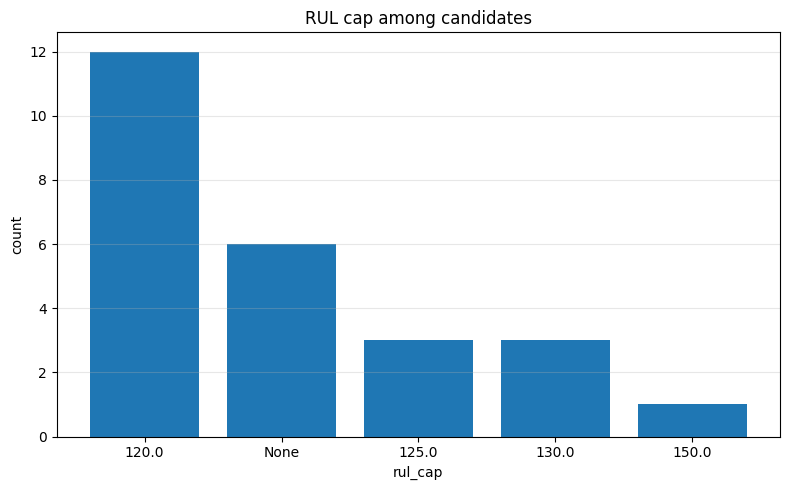

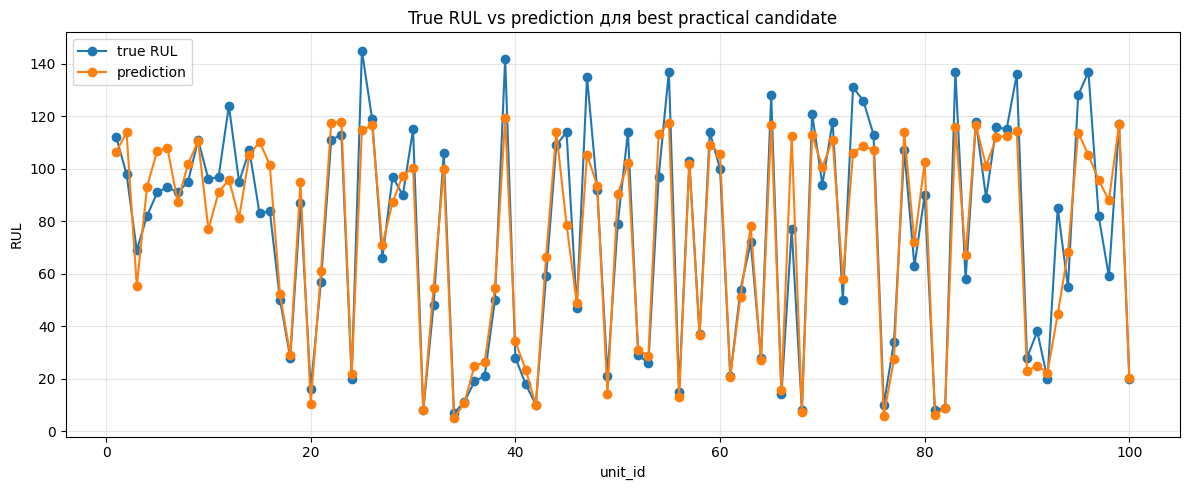

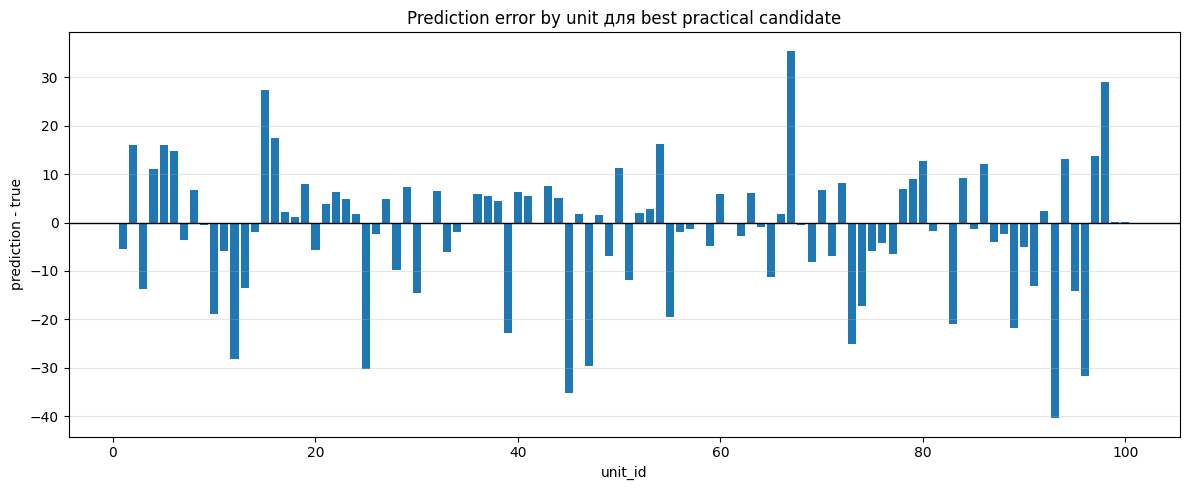

In [15]:
plot_df = official_results_df.reset_index(drop=True).copy()
plot_df["candidate_label"] = [f"c{i+1}" for i in range(len(plot_df))]

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["validation_MAE"], plot_df["official_calibrated_MAE"])
plt.xlabel("validation MAE")
plt.ylabel("official calibrated MAE")
plt.title("Validation MAE vs official calibrated MAE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["validation_fitness"], plot_df["official_calibrated_MAE"])
plt.xlabel("validation fitness")
plt.ylabel("official calibrated MAE")
plt.title("Validation fitness vs official calibrated MAE")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

for metric, title in [("official_calibrated_MAE", "Official calibrated MAE"), ("official_calibrated_overestimation_share", "Official calibrated overestimation share")]:
    plt.figure(figsize=(10, 5))
    plt.bar(plot_df["candidate_label"], plot_df[metric])
    plt.title(title)
    plt.xlabel("candidate")
    plt.ylabel(metric)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

for column, title in [("window_size", "Window size among candidates"), ("rul_cap", "RUL cap among candidates")]:
    counts = plot_df[column].fillna("None").value_counts().rename_axis(column).reset_index(name="count")
    plt.figure(figsize=(8, 5))
    plt.bar(counts[column].astype(str), counts["count"])
    plt.title(title)
    plt.xlabel(column)
    plt.ylabel("count")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

practical_hash = best_practical["candidate_hash"]
practical_error_df = error_tables[practical_hash]
plt.figure(figsize=(12, 5))
plt.plot(practical_error_df["id"], practical_error_df["true_rul"], marker="o", label="true RUL")
plt.plot(practical_error_df["id"], practical_error_df["pred_rul"], marker="o", label="prediction")
plt.title("True RUL vs prediction для best practical candidate")
plt.xlabel("unit_id")
plt.ylabel("RUL")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(practical_error_df["id"], practical_error_df["error"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Prediction error by unit для best practical candidate")
plt.xlabel("unit_id")
plt.ylabel("prediction - true")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Анализ почему validation могла обмануть

Internal validation нужна, чтобы не подбирать все параметры напрямую по official test. Однако validation может иметь distribution shift. В первой версии Week 4 validation слишком сильно поощрила capped RUL конфигурации, особенно cap=100. Такие модели хорошо работают на искусственных cutoff-точках, но на official test могут слишком сильно занижать RUL. Поэтому в новой версии мы оцениваем не одного победителя, а несколько top candidates.

## 11. Финальные выводы

Week 4 failed version показала важную проблему: лучший validation candidate не обязан быть лучшим official test candidate. Robust version исправляет это через проверку нескольких top candidates.

Если ни один evolutionary candidate не побил Week 3, честный вывод состоит в том, что Week 3 baseline остаётся основной практической моделью. Если один из кандидатов устойчиво улучшил Week 3 по official calibrated MAE и safety-метрикам, он становится новым practical candidate.

В отличие от первой версии Week 4, здесь мы не считаем одного validation-победителя финальной моделью. Эволюционный алгоритм используется как генератор перспективных конфигураций, а окончательный выбор делается после robustness check на official test. Это более аккуратная постановка: validation направляет поиск, но финальная интерпретация строится по нескольким кандидатам и safety-oriented метрикам.

## 12. Output checklist

In [16]:
expected_files = [
    "outputs/week4_robustness_candidate_list.csv",
    "outputs/week4_robust_official_results.csv",
    "outputs/week4_robust_shift_results.csv",
    "outputs/week4_robust_vs_week3_comparison.csv",
    "outputs/week4_final_recommendations.csv",
]

pd.DataFrame({"file": expected_files, "exists": [Path(file).exists() for file in expected_files]})


,file,exists
0,outputs/week4_robustness_candidate_list.csv,True
1,outputs/week4_robust_official_results.csv,True
2,outputs/week4_robust_shift_results.csv,True
3,outputs/week4_robust_vs_week3_comparison.csv,True
4,outputs/week4_final_recommendations.csv,True
